<a href="https://colab.research.google.com/github/queleandrade/estatistica_ciencias_dados---Mestrado/blob/main/Mod_I_banco2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tradução do script R para Python (Google Colab)
Este notebook replica as principais análises usando pandas, matplotlib, seaborn e scipy.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:

# Ajuste o caminho para seu arquivo no Colab
df = pd.read_excel('/content/banco2_modulo1.xls')
df.head()


,ident,salario,ingles,anosformado,estcivil,filhos,bebida
0,1,3500.0,fluente,12.0,casado,1,outra alcoolica
1,2,1800.0,nenhum,2.0,casado,3,nao alcoolica
2,3,4000.0,fluente,5.0,casado,1,outra alcoolica
3,4,4000.0,fluente,7.0,casado,3,outra alcoolica
4,5,2500.0,nenhum,11.0,casado,2,nao alcoolica


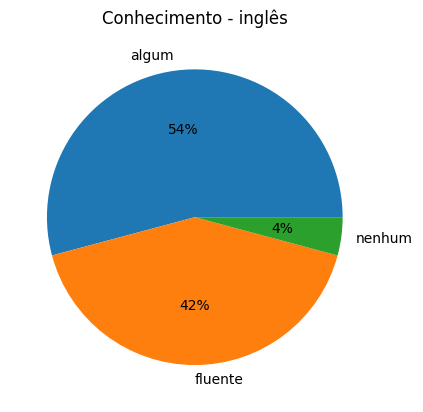

In [3]:

# Gráfico de pizza - inglês
tab_ingles = df['ingles'].value_counts()

plt.figure()
plt.pie(tab_ingles, labels=tab_ingles.index, autopct='%1.0f%%')
plt.title('Conhecimento - inglês')
plt.show()


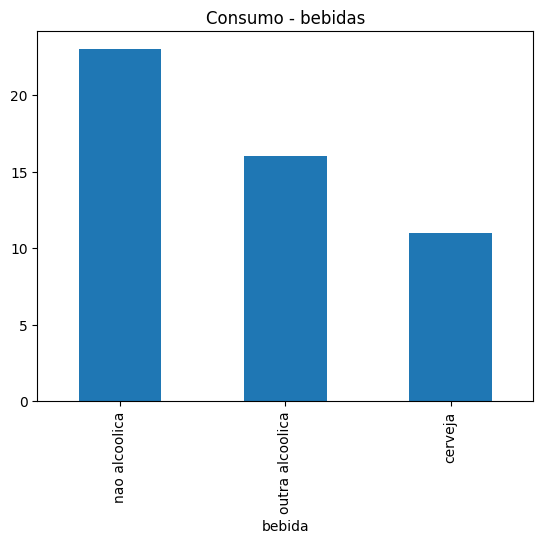

In [4]:

# Gráfico de barras - bebida
tab_bebida = df['bebida'].value_counts()

plt.figure()
tab_bebida.plot(kind='bar')
plt.title('Consumo - bebidas')
plt.show()


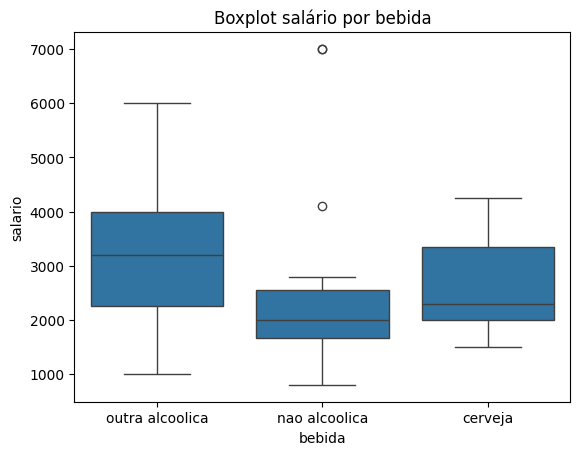

In [5]:

# Boxplot salário por bebida
plt.figure()
sns.boxplot(x='bebida', y='salario', data=df)
plt.title('Boxplot salário por bebida')
plt.show()


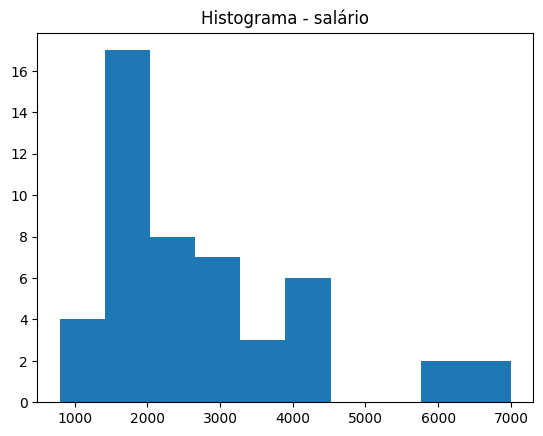

In [6]:

# Histograma
plt.figure()
plt.hist(df['salario'], bins=10)
plt.title('Histograma - salário')
plt.show()


In [7]:

# Medidas resumo
df.describe()


,ident,salario,anosformado,filhos
count,50.00000,49.000000,48.000000,50.000000
mean,25.50000,2798.979592,4.197917,0.920000
std,14.57738,1440.322945,3.815896,1.103612
min,1.00000,800.000000,0.000000,0.000000
25%,13.25000,1800.000000,1.000000,0.000000
50%,25.50000,2500.000000,3.000000,0.500000
75%,37.75000,3500.000000,7.000000,2.000000
max,50.00000,7000.000000,15.000000,4.000000


In [8]:

# Tabela cruzada
pd.crosstab(df['bebida'], df['ingles'], normalize='index') * 100


ingles,algum,fluente,nenhum
bebida,,,
cerveja,66.666667,33.333333,0.000000
nao alcoolica,56.521739,34.782609,8.695652
outra alcoolica,43.750000,56.250000,0.000000


In [9]:

# Teste Qui-quadrado
cont = pd.crosstab(df['bebida'], df['ingles'])
chi2, p, dof, expected = stats.chi2_contingency(cont)

chi2, p


(np.float64(4.005852842809364), np.float64(0.40521433307185456))

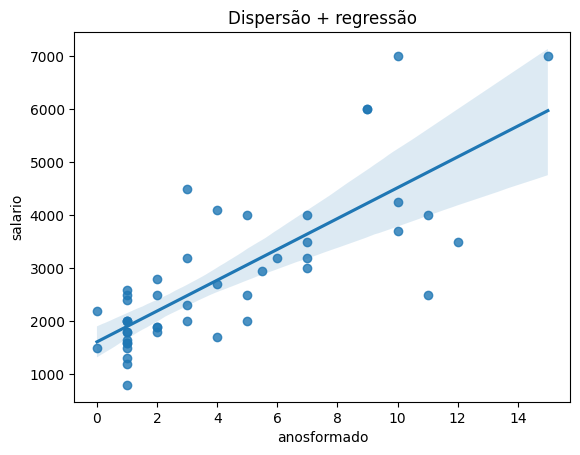

In [10]:

# Dispersão com regressão
sns.regplot(x='anosformado', y='salario', data=df)
plt.title('Dispersão + regressão')
plt.show()


In [11]:

# Correlação
df[['salario','anosformado']].corr()


,salario,anosformado
salario,1.000000,0.772731
anosformado,0.772731,1.000000


In [12]:

# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

modelo = ols('salario ~ C(estcivil)', data=df).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
anova_table


,sum_sq,df,F,PR(>F)
C(estcivil),1.756505e+07,2.0,4.926038,0.011522
Residual,8.201240e+07,46.0,NaN,NaN
